In [ ]:
import sys
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from gpt import MiniGPT
from bpe_tokenizer import BPETokenizer

sys.modules['__main__'].BPETokenizer = BPETokenizer

device = torch.device('cpu')

vocab = torch.load('vocab.bin', map_location=device, weights_only=False)
if 'bpe' in vocab:
    bpe = vocab['bpe']
    encode = bpe.encode_ids
    decode = bpe.decode_ids
    itos = bpe.itos
    vocab_size = len(bpe.stoi)
else:
    stoi = vocab['stoi']
    itos = vocab['itos']
    encode = lambda s: [stoi[c] for c in s]
    decode = lambda l: ''.join([itos[i] for i in l])
    vocab_size = len(stoi)

model = MiniGPT(vocab_size, 384, 12, 6, 256, 0.0)
model.load_state_dict(torch.load('minigpt_weights.pth', map_location=device))
model.eval()


MiniGPT(
  (token_embedding): Embedding(7108, 384)
  (pos_embedding): LearnedPositionalEmbedding(
    (embedding): Embedding(256, 384)
  )
  (dropout): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-5): 6 x DecoderBlock(
      (mha): MultiHeadAttention(
        (q_linear): Linear(in_features=384, out_features=384, bias=True)
        (k_linear): Linear(in_features=384, out_features=384, bias=True)
        (v_linear): Linear(in_features=384, out_features=384, bias=True)
        (out_linear): Linear(in_features=384, out_features=384, bias=True)
      )
      (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True, bias=True)
      (dropout1): Dropout(p=0.0, inplace=False)
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=384, out_features=1536, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=1536, out_features=384, bias=True)
          (4): Dropout(p=0

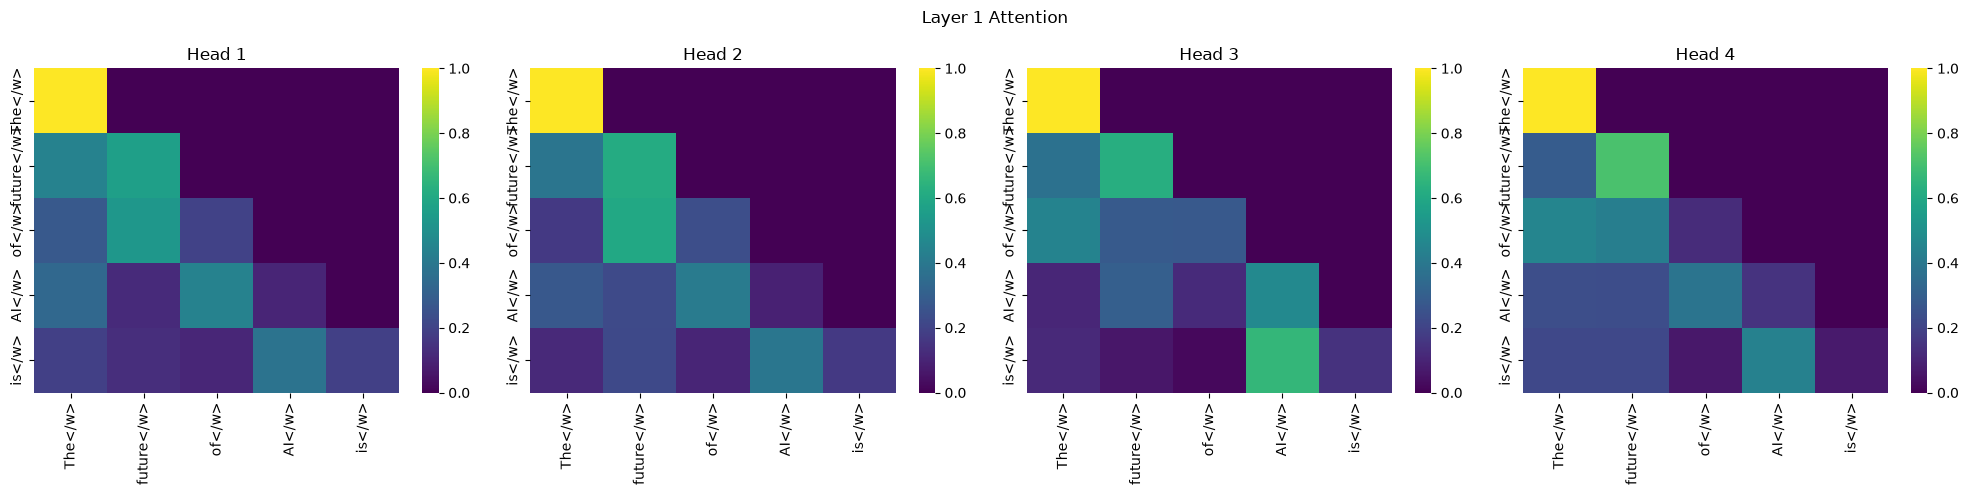

In [ ]:
attention_weights = []

def hook_fn(module, input, output):
    attention_weights.append(output[1].detach())

hooks = []
for block in model.blocks:
    hooks.append(block.mha.register_forward_hook(hook_fn))
    
text = "The future of AI is"
idx = torch.tensor([encode(text)], dtype=torch.long)
tokens = [itos[i.item()] for i in idx[0]]

_, _ = model(idx)

for h in hooks:
    h.remove()
    

layer = 0
weights = attention_weights[layer][0]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for h in range(4):
    sns.heatmap(weights[h].numpy(), ax=axes[h], xticklabels=tokens, yticklabels=tokens, cmap='viridis')
    axes[h].set_title(f"Head {h+1}")
plt.suptitle(f"Layer {layer+1} Attention")
plt.tight_layout()
plt.show()
